In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/flowboat/nlp-code/valid-00000-of-00001.parquet
/kaggle/input/datasets/flowboat/nlp-code/train-00000-of-00001.parquet
/kaggle/input/datasets/minhfli/vncorenlp-summary/test_masked.parquet
/kaggle/input/datasets/minhfli/vncorenlp-summary/test_masked2.parquet
/kaggle/input/datasets/minhfli/vncorenlp-summary/train_tokenized.parquet
/kaggle/input/datasets/minhfli/vncorenlp-summary/test_tokenized.parquet
/kaggle/input/datasets/minhfli/vncorenlp-summary/train_masked2.parquet
/kaggle/input/datasets/minhfli/vncorenlp-summary/train_masked.parquet


In [3]:
raw_train_df = pd.read_parquet("/kaggle/input/datasets/flowboat/nlp-code/train-00000-of-00001.parquet")
raw_valid_df = pd.read_parquet("/kaggle/input/datasets/flowboat/nlp-code/valid-00000-of-00001.parquet")

train_df = pd.read_parquet("/kaggle/input/datasets/minhfli/vncorenlp-summary/train_tokenized.parquet")
valid_df = pd.read_parquet("/kaggle/input/datasets/minhfli/vncorenlp-summary/test_tokenized.parquet")

print(raw_train_df.head())
print(train_df.head())

                                             article  \
0  Gần 20 sự kiện được tổ chức trên toàn thành ph...   
1  Được thành lập năm 1897 tại Đức, Kempinski Hot...   
2  Ngoài di chuyển đến Tuần Châu bằng đường bộ, m...   
3  Với những tín đồ Phật giáo, bức tượng Phật ngọ...   
4  Số liệu của Tổng cục Thống kê công bố sáng 29/...   

                                             summary  
0  Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...  
1  Kempinski Hotels là một thương hiệu nổi tiếng ...  
2  Bài viết giới thiệu các hoạt động vui chơi giả...  
3  Bức tượng Phật ngọc hòa bình thế giới, được vợ...  
4  Trong tháng 4, Việt Nam tiếp tục đón khách quố...  
                                   article_tokenized  \
0  Gần 20 sự_kiện được tổ_chức trên toàn thành_ph...   
1  Được thành_lập năm 1897 tại Đức , Kempinski_Ho...   
2  Ngoài di_chuyển đến Tuần_Châu bằng đường_bộ , ...   
3  Với những tín_đồ Phật_giáo , bức tượng Phật ng...   
4  Số_liệu của Tổng_cục Thống_kê công_bố sáng 29/... 

In [5]:
import re

def separate_punctuation(text):
    # tách mọi dấu câu thành token riêng
    text = re.sub(r'([^\w\s])', r' \1 ', str(text))
    # chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    return text

raw_train_df["article"] = raw_train_df["article"].apply(separate_punctuation)
raw_train_df["summary"] = raw_train_df["summary"].apply(separate_punctuation)

DATASET STATISTICS

Number of samples: 10,775

RAW TEXT LENGTH STATISTICS
--------------------------------------------------------------------------------
        Article  Summary
Min      328.00    52.00
Max     1011.00   199.00
Mean     526.17   115.07
Median   510.00   112.00
Std      113.52    24.30

Compression Ratio (Raw)
Mean   : 0.2264
Median : 0.2211
Std    : 0.0593

TOKENIZED LENGTH STATISTICS
--------------------------------------------------------------------------------
        Article  Summary
Min      214.00    36.00
Max      716.00   173.00
Mean     405.96    86.48
Median   390.00    84.00
Std       92.82    18.82

Compression Ratio (Tokenized)
Mean   : 0.2215
Median : 0.2165
Std    : 0.0602

VOCABULARY
--------------------------------------------------------------------------------
Article vocabulary size : 110,842
Summary vocabulary size : 40,350
Total vocabulary size   : 112,234

LEXICAL OVERLAP
------------------------------------------------------------------------

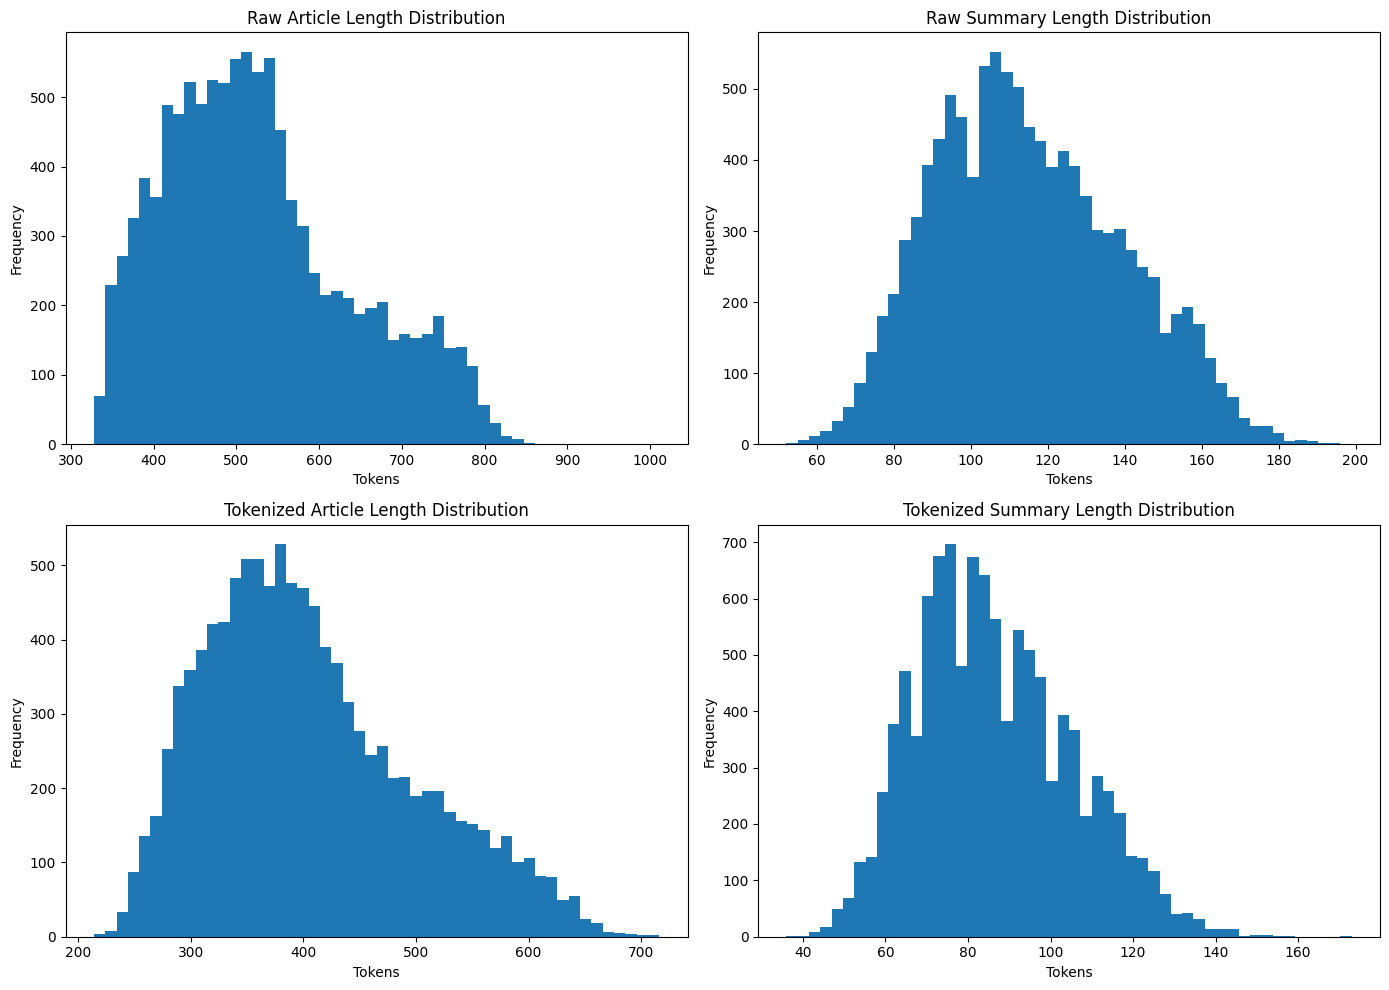

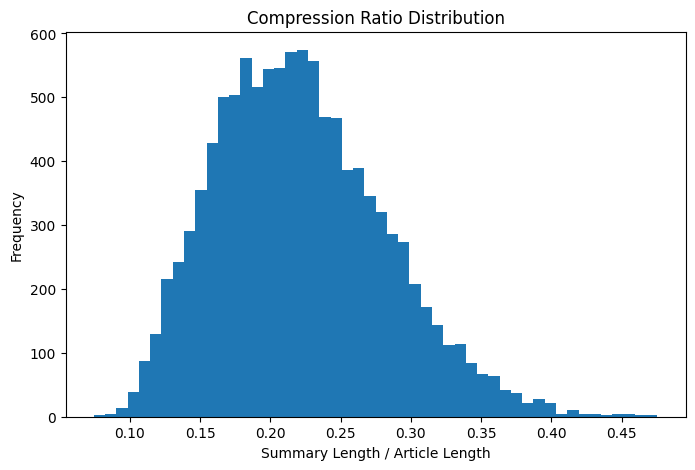

In [8]:
import pandas as pd
import numpy as np

print("=" * 80)
print("DATASET STATISTICS")
print("=" * 80)

# =====================================================
# BASIC INFO
# =====================================================
n_samples = len(train_df)

print(f"\nNumber of samples: {n_samples:,}")

# =====================================================
# RAW TEXT STATISTICS
# =====================================================
raw_article_len = raw_train_df["article"].str.split().apply(len)
raw_summary_len = raw_train_df["summary"].str.split().apply(len)

# =====================================================
# TOKENIZED STATISTICS
# =====================================================
tok_article_len = train_df["article_tokenized"].str.split().apply(len)
tok_summary_len = train_df["summary_tokenized"].str.split().apply(len)

# =====================================================
# FUNCTION
# =====================================================
def build_stats(article_len, summary_len):
    return pd.DataFrame({
        "Article": [
            article_len.min(),
            article_len.max(),
            article_len.mean(),
            article_len.median(),
            article_len.std()
        ],
        "Summary": [
            summary_len.min(),
            summary_len.max(),
            summary_len.mean(),
            summary_len.median(),
            summary_len.std()
        ]
    }, index=["Min", "Max", "Mean", "Median", "Std"])

# =====================================================
# RAW STATS
# =====================================================
print("\nRAW TEXT LENGTH STATISTICS")
print("-" * 80)

raw_stats = build_stats(raw_article_len, raw_summary_len)
print(raw_stats.round(2))

raw_cr = raw_summary_len / raw_article_len

print("\nCompression Ratio (Raw)")
print(f"Mean   : {raw_cr.mean():.4f}")
print(f"Median : {raw_cr.median():.4f}")
print(f"Std    : {raw_cr.std():.4f}")

# =====================================================
# TOKENIZED STATS
# =====================================================
print("\nTOKENIZED LENGTH STATISTICS")
print("-" * 80)

tok_stats = build_stats(tok_article_len, tok_summary_len)
print(tok_stats.round(2))

tok_cr = tok_summary_len / tok_article_len

print("\nCompression Ratio (Tokenized)")
print(f"Mean   : {tok_cr.mean():.4f}")
print(f"Median : {tok_cr.median():.4f}")
print(f"Std    : {tok_cr.std():.4f}")

# =====================================================
# VOCABULARY SIZE
# =====================================================
article_vocab = set()
summary_vocab = set()

for text in train_df["article_tokenized"]:
    article_vocab.update(text.split())

for text in train_df["summary_tokenized"]:
    summary_vocab.update(text.split())

total_vocab = article_vocab | summary_vocab

print("\nVOCABULARY")
print("-" * 80)
print(f"Article vocabulary size : {len(article_vocab):,}")
print(f"Summary vocabulary size : {len(summary_vocab):,}")
print(f"Total vocabulary size   : {len(total_vocab):,}")

# =====================================================
# LEXICAL OVERLAP
# =====================================================
print("\nLEXICAL OVERLAP")
print("-" * 80)

def lexical_overlap(article, summary):
    article_set = set(article.split())
    summary_set = set(summary.split())

    if len(summary_set) == 0:
        return 0

    return len(article_set & summary_set) / len(summary_set)

overlaps = [
    lexical_overlap(a, s)
    for a, s in zip(
        train_df["article_tokenized"],
        train_df["summary_tokenized"]
    )
]

overlaps = np.array(overlaps)

print(f"Mean overlap   : {overlaps.mean():.4f}")
print(f"Median overlap : {np.median(overlaps):.4f}")
print(f"Std overlap    : {overlaps.std():.4f}")

# =====================================================
# NOVEL UNIGRAM
# =====================================================
print("\nNOVEL UNIGRAM")
print("-" * 80)

def novel_unigram(article, summary):
    article_set = set(article.split())
    summary_tokens = summary.split()

    if len(summary_tokens) == 0:
        return 0

    novel = sum(
        1 for token in summary_tokens
        if token not in article_set
    )

    return novel / len(summary_tokens)

novel_scores = [
    novel_unigram(a, s)
    for a, s in zip(
        train_df["article_tokenized"],
        train_df["summary_tokenized"]
    )
]

novel_scores = np.array(novel_scores)

print(f"Mean novel unigram   : {novel_scores.mean():.4f}")
print(f"Median novel unigram : {np.median(novel_scores):.4f}")
print(f"Std novel unigram    : {novel_scores.std():.4f}")

# =====================================================
# FINAL SUMMARY TABLE
# =====================================================
summary_table = pd.DataFrame({
    "Metric": [
        "Number of samples",
        "Avg article length (raw)",
        "Avg summary length (raw)",
        "Avg article length (tokenized)",
        "Avg summary length (tokenized)",
        "Compression ratio",
        "Vocabulary size",
        "Lexical overlap",
        "Novel unigram ratio"
    ],
    "Value": [
        f"{n_samples:,}",
        f"{raw_article_len.mean():.2f}",
        f"{raw_summary_len.mean():.2f}",
        f"{tok_article_len.mean():.2f}",
        f"{tok_summary_len.mean():.2f}",
        f"{tok_cr.mean():.4f}",
        f"{len(total_vocab):,}",
        f"{overlaps.mean():.4f}",
        f"{novel_scores.mean():.4f}"
    ]
})

print("\nFINAL SUMMARY")
print("=" * 80)
print(summary_table)
import matplotlib.pyplot as plt

# =========================
# LENGTH DISTRIBUTIONS
# =========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Raw article
axes[0, 0].hist(raw_article_len, bins=50)
axes[0, 0].set_title("Raw Article Length Distribution")
axes[0, 0].set_xlabel("Tokens")
axes[0, 0].set_ylabel("Frequency")

# Raw summary
axes[0, 1].hist(raw_summary_len, bins=50)
axes[0, 1].set_title("Raw Summary Length Distribution")
axes[0, 1].set_xlabel("Tokens")
axes[0, 1].set_ylabel("Frequency")

# Tokenized article
axes[1, 0].hist(tok_article_len, bins=50)
axes[1, 0].set_title("Tokenized Article Length Distribution")
axes[1, 0].set_xlabel("Tokens")
axes[1, 0].set_ylabel("Frequency")

# Tokenized summary
axes[1, 1].hist(tok_summary_len, bins=50)
axes[1, 1].set_title("Tokenized Summary Length Distribution")
axes[1, 1].set_xlabel("Tokens")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# =========================
# COMPRESSION RATIO
# =========================

plt.figure(figsize=(8, 5))
plt.hist(tok_cr, bins=50)
plt.title("Compression Ratio Distribution")
plt.xlabel("Summary Length / Article Length")
plt.ylabel("Frequency")
plt.show()